# Задание 1

In [ ]:
pip install pandas

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

file_path = 'data.csv'
data = pd.read_csv(file_path)

## График траекторий

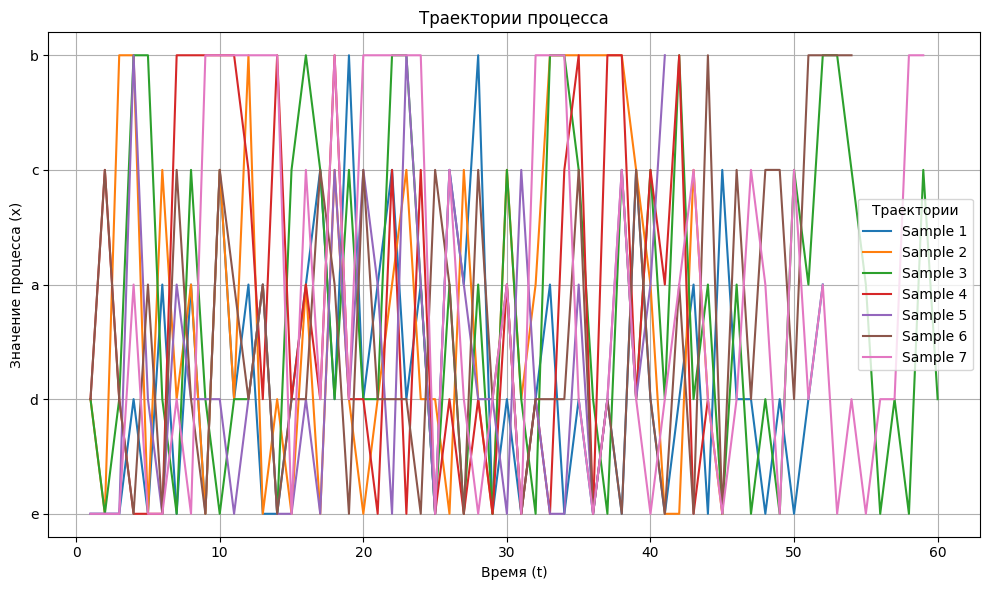

In [3]:
plt.figure(figsize=(10, 6))

for sample in data['sample'].unique():
    trajectory = data[data['sample'] == sample]
    plt.plot(trajectory['t'], trajectory['x'], label=f'Sample {sample}')

# Настройки графика
plt.title('Траектории процесса')
plt.xlabel('Время (t)')
plt.ylabel('Значение процесса (x)')
plt.legend(title='Траектории')
plt.grid(True)
plt.tight_layout()

# Показ графика
plt.show()

## ОМП для π и P по нескольким выборочным траекториям
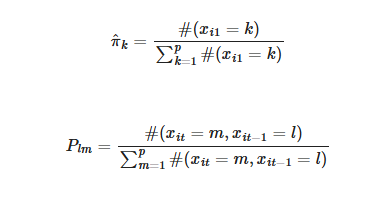

In [5]:
p = data['x'].nunique()
def get_prob(data, l, m):
	cntlm = 0
	cntl = 0
	for i in range(data.shape[0] - 1):
		if data[i, 2] == l and data[i+1, 2] == m and data[i, 0] == data[i+1, 0]:
			cntlm += 1 #  количество раз, когда состояние l переходит в состояние m для одного и того же объекта.
		if data[i, 2] == l and data[i, 0] == data[i+1, 0]:
			cntl += 1 #  количество раз, когда состояние l встречается для одного и того же объекта.
	return cntlm/cntl
def get_estimation(data):
	Pi = np.zeros(p)
	P = np.zeros((p,p))
	data_first = data[np.where(data[:,1] == 1)][:, 2]
	for k in range(len(Pi)):
		Pi[k] = sum(data_first == k+1) / len(data_first)
	for i in range(p):
		for j in range(p):
			P[i,j] = get_prob(data, i+1, j+1)
	return (Pi, P)

In [6]:
x_to_i = dict()
for i, x in enumerate(sorted(data['x'].unique())):
	x_to_i[x] = i + 1
data['x'] = data['x'].apply(lambda x: x_to_i[x])

In [7]:
Pi, P = get_estimation(np.array(data))

In [8]:
Pi

array([0.        , 0.        , 0.        , 0.57142857, 0.42857143])

In [9]:
P

array([[0.        , 0.11363636, 0.09090909, 0.09090909, 0.70454545],
       [0.03703704, 0.55555556, 0.09259259, 0.16666667, 0.14814815],
       [0.2037037 , 0.03703704, 0.01851852, 0.68518519, 0.05555556],
       [0.20408163, 0.1122449 , 0.12244898, 0.14285714, 0.41836735],
       [0.12244898, 0.09183673, 0.32653061, 0.32653061, 0.13265306]])

## 4) Пусть $( X_1,..., X_n )$ — значения из первой выборочной траектории (где \( n \) — последний момент времени, для которого присутствует наблюдение в выборочной траектории). Исходя из полученных оценок для начального распределения и матрицы переходных вероятностей, вычислите условные вероятности: $P(\xi(n+1) = x \mid X_1,..., X_n)$ и $P(\xi(n+2) = x \mid X_1,..., X_n)$ для всех x $\in$ $\text{dom}\xi$.

In [10]:
xn = data[data['sample'] == 1]["x"].values[-1]
def get_prediction(P):
	P_xi_nplus1 = P[xn-1, :] # берем строку xn матрицы перехода
	P_xi_nplus2 = P_xi_nplus1 @ P
	return P_xi_nplus1, P_xi_nplus2
P_xi_nplus1, P_xi_nplus2 = get_prediction(P)
print("P(xi(n+1) = x | X1,...,Xn):", P_xi_nplus1)
print("P(xi(n+2) = x | X1,...,Xn):", P_xi_nplus2)

P(xi(n+1) = x | X1,...,Xn): [0.         0.11363636 0.09090909 0.09090909 0.70454545]
P(xi(n+2) = x | X1,...,Xn): [0.12755102 0.14140555 0.25339277 0.32427163 0.15337903]


# Задание 2

In [11]:
import random
def generate_markov_trajectory(pi,P,sample,max_t):
    t1 = np.random.choice(len(pi), p=pi)
    trajectory = [[sample, 1, t1 + 1]]

    for t in range(1, max_t):
        current_state = trajectory[-1][2] - 1
        next_state = np.random.choice(len(P), p=P[current_state])
        trajectory.append([sample, t+1, next_state + 1])

    return trajectory

In [12]:
a = generate_markov_trajectory(Pi,P,1,5)
a

[[1, 1, 5], [1, 2, 4], [1, 3, 2], [1, 4, 2], [1, 5, 2]]

In [98]:
from tqdm import tqdm
pi_results = []
P_results = []
last_records = []

pt1_result = []
pt2_result = []

max_t_per_sample = data.groupby('sample')['t'].max()
for k in tqdm(range(1000), desc="Итерации"):
    trajectories = []
    for sample in range(1,8):
        max_t = max_t_per_sample.get(sample, random.randint(45, 60))
        traj = generate_markov_trajectory(Pi,P,sample,max_t)
        trajectories.extend(traj)

    new_data = pd.DataFrame(trajectories, columns=["sample", "t", "x"])
    last_record = new_data[new_data['sample'] == 1].iloc[-1]

    Pi_new, P_new = get_estimation(np.array(new_data))

    pi_results.append(Pi_new)
    P_results.append(P_new)
    last_records.append(last_record)




Итерации: 100%|██████████| 1000/1000 [00:13<00:00, 75.67it/s]


In [ ]:
pi_results

# Дисперсии для $\pi$ и $P$

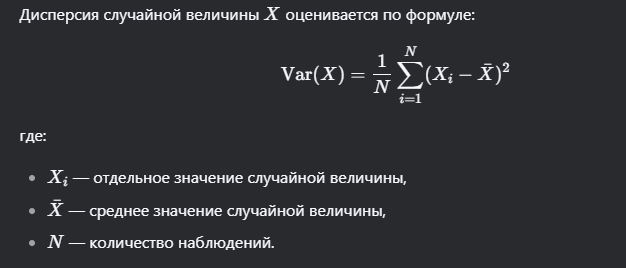

In [107]:
pi_results

[array([0.        , 0.        , 0.        , 0.85714286, 0.14285714]),
 array([0.        , 0.        , 0.        , 0.85714286, 0.14285714]),
 array([0.        , 0.        , 0.        , 0.57142857, 0.42857143]),
 array([0.        , 0.        , 0.        , 0.42857143, 0.57142857]),
 array([0.        , 0.        , 0.        , 0.42857143, 0.57142857]),
 array([0.        , 0.        , 0.        , 0.42857143, 0.57142857]),
 array([0.        , 0.        , 0.        , 0.28571429, 0.71428571]),
 array([0.        , 0.        , 0.        , 0.28571429, 0.71428571]),
 array([0.        , 0.        , 0.        , 0.71428571, 0.28571429]),
 array([0.        , 0.        , 0.        , 0.28571429, 0.71428571]),
 array([0.        , 0.        , 0.        , 0.57142857, 0.42857143]),
 array([0., 0., 0., 1., 0.]),
 array([0.        , 0.        , 0.        , 0.42857143, 0.57142857]),
 array([0.        , 0.        , 0.        , 0.57142857, 0.42857143]),
 array([0.        , 0.        , 0.        , 0.85714286, 0.14

In [99]:
def get_variance(pi_results,P_results):
    # Оценка дисперсии для pi
    pi_var = np.var(pi_results, axis=0)  # Дисперсия для каждого элемента pi
    # Оценка дисперсии для P
    P_var = np.var(P_results, axis=0)  # Дисперсия для каждого элемента P

    df_pi = pd.DataFrame({
        'Дисперсия': pi_var})
    df_P_var = pd.DataFrame(P_var, columns=[i + 1 for i in range(P_var.shape[1])],
                            index=[i + 1 for i in range(P_var.shape[0])])
    print("\nДисперсия для pi")
    display(df_pi)
    print("\nДисперсия для P:")
    display(df_P_var)


In [100]:
get_variance(pi_results,P_results)


Дисперсия для pi


,Дисперсия
0,0.000000
1,0.000000
2,0.000000
3,0.035666
4,0.035666



Дисперсия для P:


,1,2,3,4,5
1,0.000000,0.002312,0.001971,0.001861,0.004824
2,0.000617,0.004747,0.001603,0.002491,0.002364
3,0.003024,0.000662,0.000343,0.004207,0.001016
4,0.001775,0.001008,0.001131,0.001216,0.002547
5,0.001140,0.000835,0.002102,0.002155,0.001243


## 0.9 Квантиль Для $P(\xi(n+1))$ и 0.9 Квантиль Для $P(\xi(n+2))$

In [101]:
def get_future_step(current_state, P, step):
    # Вычисляем вероятности через step шагов
    future_prob = np.linalg.matrix_power(P, step)[current_state]
    return future_prob

In [102]:

def get_quantile(P_results):
    first_sample_trajectory = data[data['sample'] == 1]["x"].tolist()

    pt1_results = []  # Для P(xi(n+1))
    pt2_results = []  # Для P(xi(n+2))

    # Текущее состояние (последнее значение первой траектории)
    current_state = first_sample_trajectory[-1] - 1  # Индексация с 0

    # Вычисляем прогнозы для каждой оценки параметров
    for P in P_results:
        pt1 = get_future_step(current_state, P, 1)
        pt2 = get_future_step(current_state, P, 2)
        pt1_results.append(pt1)
        pt2_results.append(pt2)

    pt1_results = np.array(pt1_results)
    pt2_results = np.array(pt2_results)

    std_pt1 = np.std(pt1_results, axis=0)  # Для P(xi(n+1)) (среднеквадратическое отклонение)
    std_pt2 = np.std(pt2_results, axis=0)  # Для P(xi(n+2))

    print("Стандартные отклонения для P(xi(n+1)):", std_pt1)
    print("Стандартные отклонения для P(xi(n+2)):", std_pt2)

    # Квантильные интервалы для P(xi(n+1))
    pt1_lower = np.quantile(pt1_results, 0.05, axis=0)
    pt1_upper = np.quantile(pt1_results, 0.95, axis=0)

    # Квантильные интервалы для P(xi(n+2))
    pt2_lower = np.quantile(pt2_results, 0.05, axis=0)
    pt2_upper = np.quantile(pt2_results, 0.95, axis=0)

    print("0.9 квантильные интервалы для P(xi(n+1)):")
    for i, (lower, upper) in enumerate(zip(pt1_lower, pt1_upper)):
        print(f"Состояние {i+1}: [{lower:.4f}, {upper:.4f}]")

    print("0.9 квантильные интервалы для P(xi(n+2)):")
    for i, (lower, upper) in enumerate(zip(pt2_lower, pt2_upper)):
        print(f"Состояние {i+1}: [{lower:.4f}, {upper:.4f}]")

In [103]:
get_quantile(P_results)

Стандартные отклонения для P(xi(n+1)): [0.         0.04808705 0.04439531 0.04314309 0.06945292]
Стандартные отклонения для P(xi(n+2)): [0.02565936 0.03117673 0.03673154 0.04028305 0.02877367]
0.9 квантильные интервалы для P(xi(n+1)):
Состояние 1: [0.0000, 0.0000]
Состояние 2: [0.0417, 0.1951]
Состояние 3: [0.0244, 0.1698]
Состояние 4: [0.0238, 0.1667]
Состояние 5: [0.5909, 0.8158]
0.9 квантильные интервалы для P(xi(n+2)):
Состояние 1: [0.0850, 0.1692]
Состояние 2: [0.0942, 0.1972]
Состояние 3: [0.1950, 0.3144]
Состояние 4: [0.2587, 0.3935]
Состояние 5: [0.1053, 0.1985]


## Гистограммы для p{0,0} p{2,1} p{2,4} и pi{1}, pi{3}, pi{0}

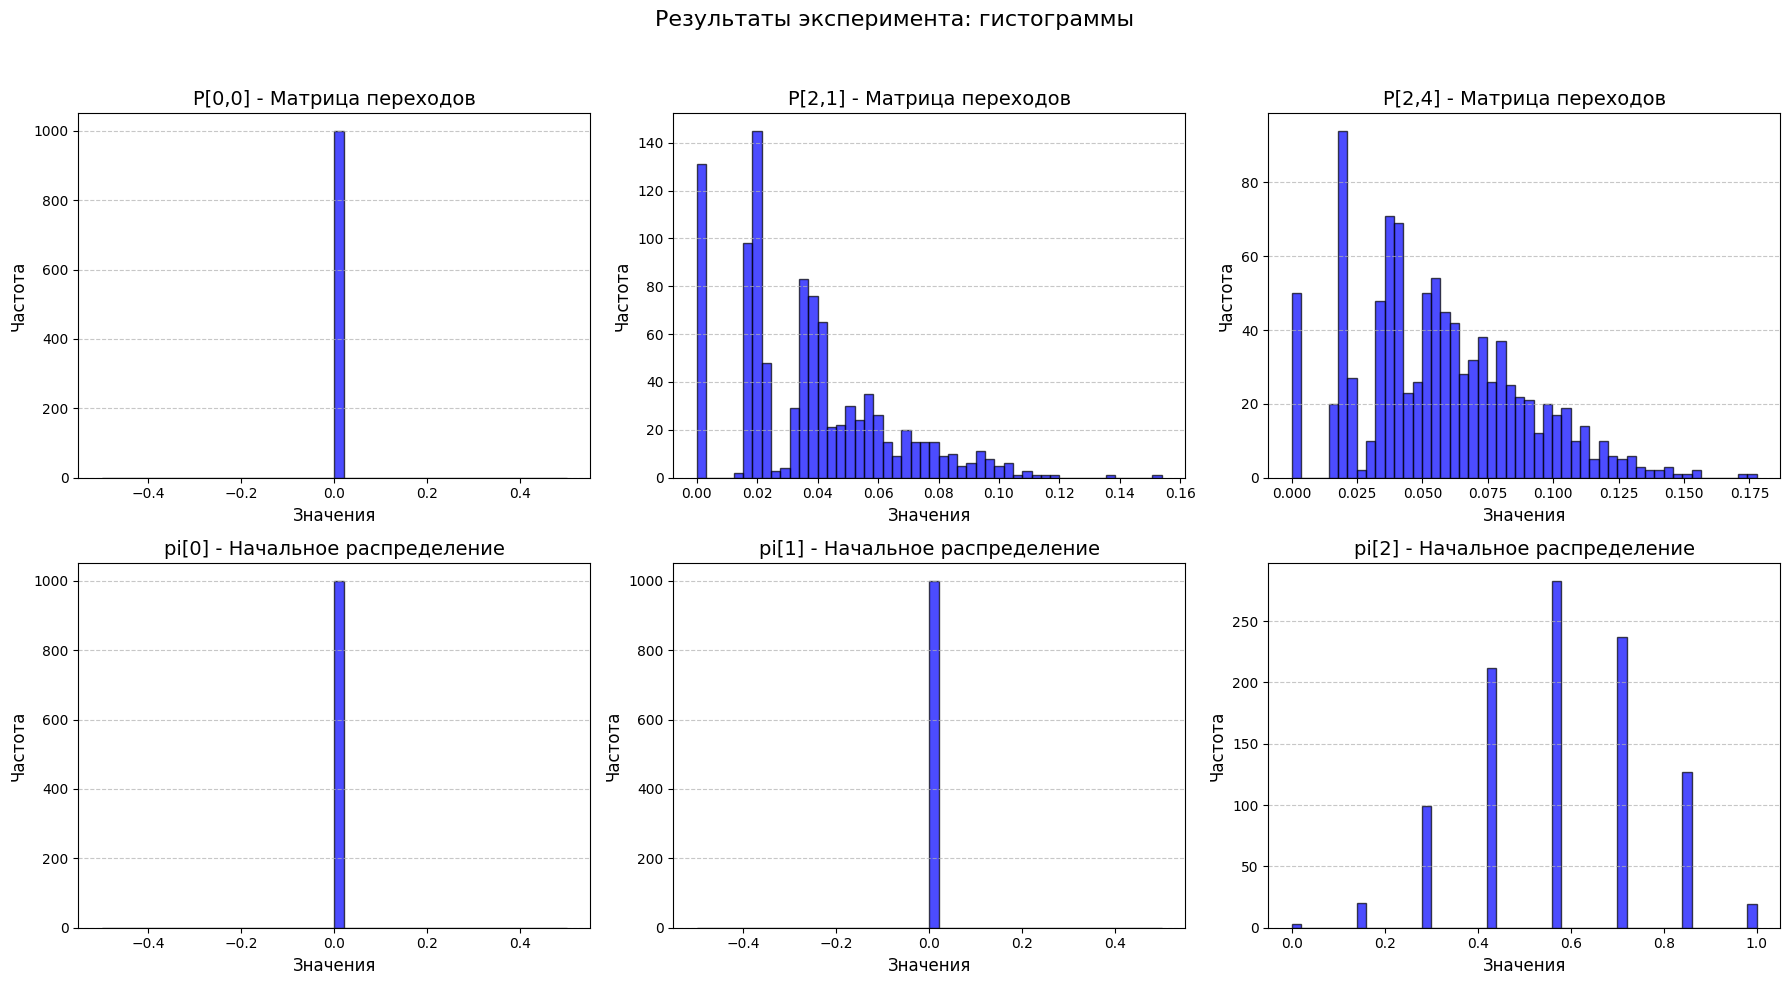

In [104]:
def plot_experiment_histograms(pi_results, P_results, bins=50):
    # Выбираем нужные элементы для визуализации
    p00 = P_results[:, 0, 0]  # Все P[0,0] из каждой итерации
    p21 = P_results[:, 2, 1]  # Все P[2,1]
    p24 = P_results[:, 2, 4]  # Все P[2,4]

    pi0 = pi_results[:, 0]  # Все pi[0]
    pi1 = pi_results[:, 1]  # Все pi[1]
    pi3 = pi_results[:, 3]  # Все pi[3]

    # Названия для графиков
    titles = [
        "P[0,0] - Матрица переходов",
        "P[2,1] - Матрица переходов",
        "P[2,4] - Матрица переходов",
        "pi[0] - Начальное распределение",
        "pi[1] - Начальное распределение",
        "pi[2] - Начальное распределение"
    ]

    data_list = [p00, p21, p24, pi0, pi1, pi3]

    # Настраиваем сетку графиков
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()
    for i, (data, title) in enumerate(zip(data_list, titles)):
        axes[i].hist(data, bins=bins, color="blue", edgecolor="black", alpha=0.7)
        axes[i].set_title(title, fontsize=14)
        axes[i].set_xlabel("Значения", fontsize=12)
        axes[i].set_ylabel("Частота", fontsize=12)
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    plt.suptitle("Результаты эксперимента: гистограммы", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_experiment_histograms(np.array(pi_results), np.array(P_results),bins = 50)

## Способ 10.2
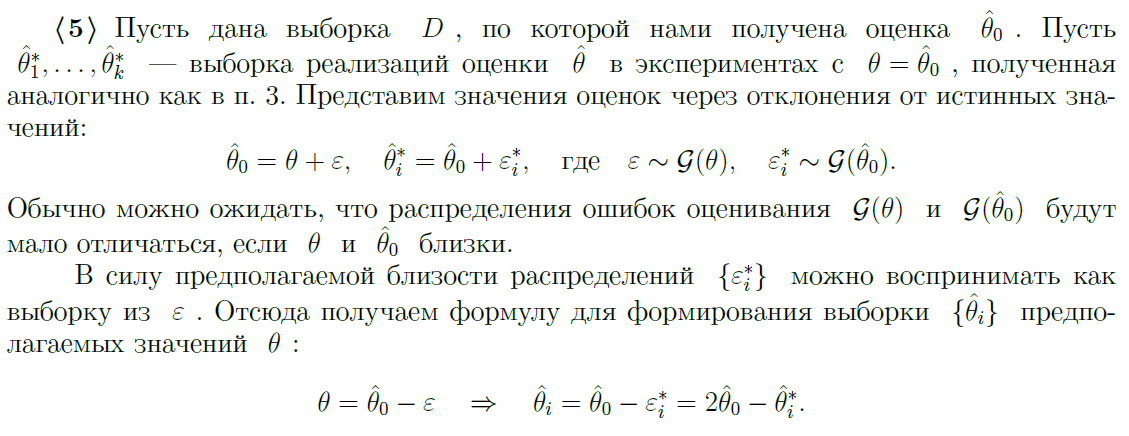

In [71]:
tetta_P = np.clip(2 * P - P_results, 0, 1)
tetta_pi = np.clip(2 * Pi - pi_results, 0, 1)

In [72]:
get_variance(tetta_pi,tetta_P)


Дисперсия для pi


,Дисперсия
0,0.000000
1,0.000000
2,0.000000
3,0.036283
4,0.036283



Дисперсия для P:


,1,2,3,4,5
1,0.000000,0.002129,0.001827,0.001748,0.004689
2,0.000497,0.004130,0.001416,0.002591,0.002112
3,0.003025,0.000515,0.000202,0.004307,0.000876
4,0.001566,0.001192,0.001116,0.001278,0.002504
5,0.001082,0.000849,0.002335,0.002327,0.001155


In [73]:
get_quantile(tetta_P)

Стандартные отклонения для P(xi(n+1)): [0.         0.04613872 0.04274652 0.04181381 0.06847475]
Стандартные отклонения для P(xi(n+2)): [0.02512091 0.03110576 0.04022886 0.04201625 0.02954233]
0.9 квантильные интервалы для P(xi(n+1)):
Состояние 1: [0.0000, 0.0000]
Состояние 2: [0.0310, 0.1847]
Состояние 3: [0.0116, 0.1586]
Состояние 4: [0.0152, 0.1586]
Состояние 5: [0.5965, 0.8196]
0.9 квантильные интервалы для P(xi(n+2)):
Состояние 1: [0.0852, 0.1675]
Состояние 2: [0.0890, 0.1910]
Состояние 3: [0.1895, 0.3223]
Состояние 4: [0.2551, 0.3928]
Состояние 5: [0.1034, 0.2025]


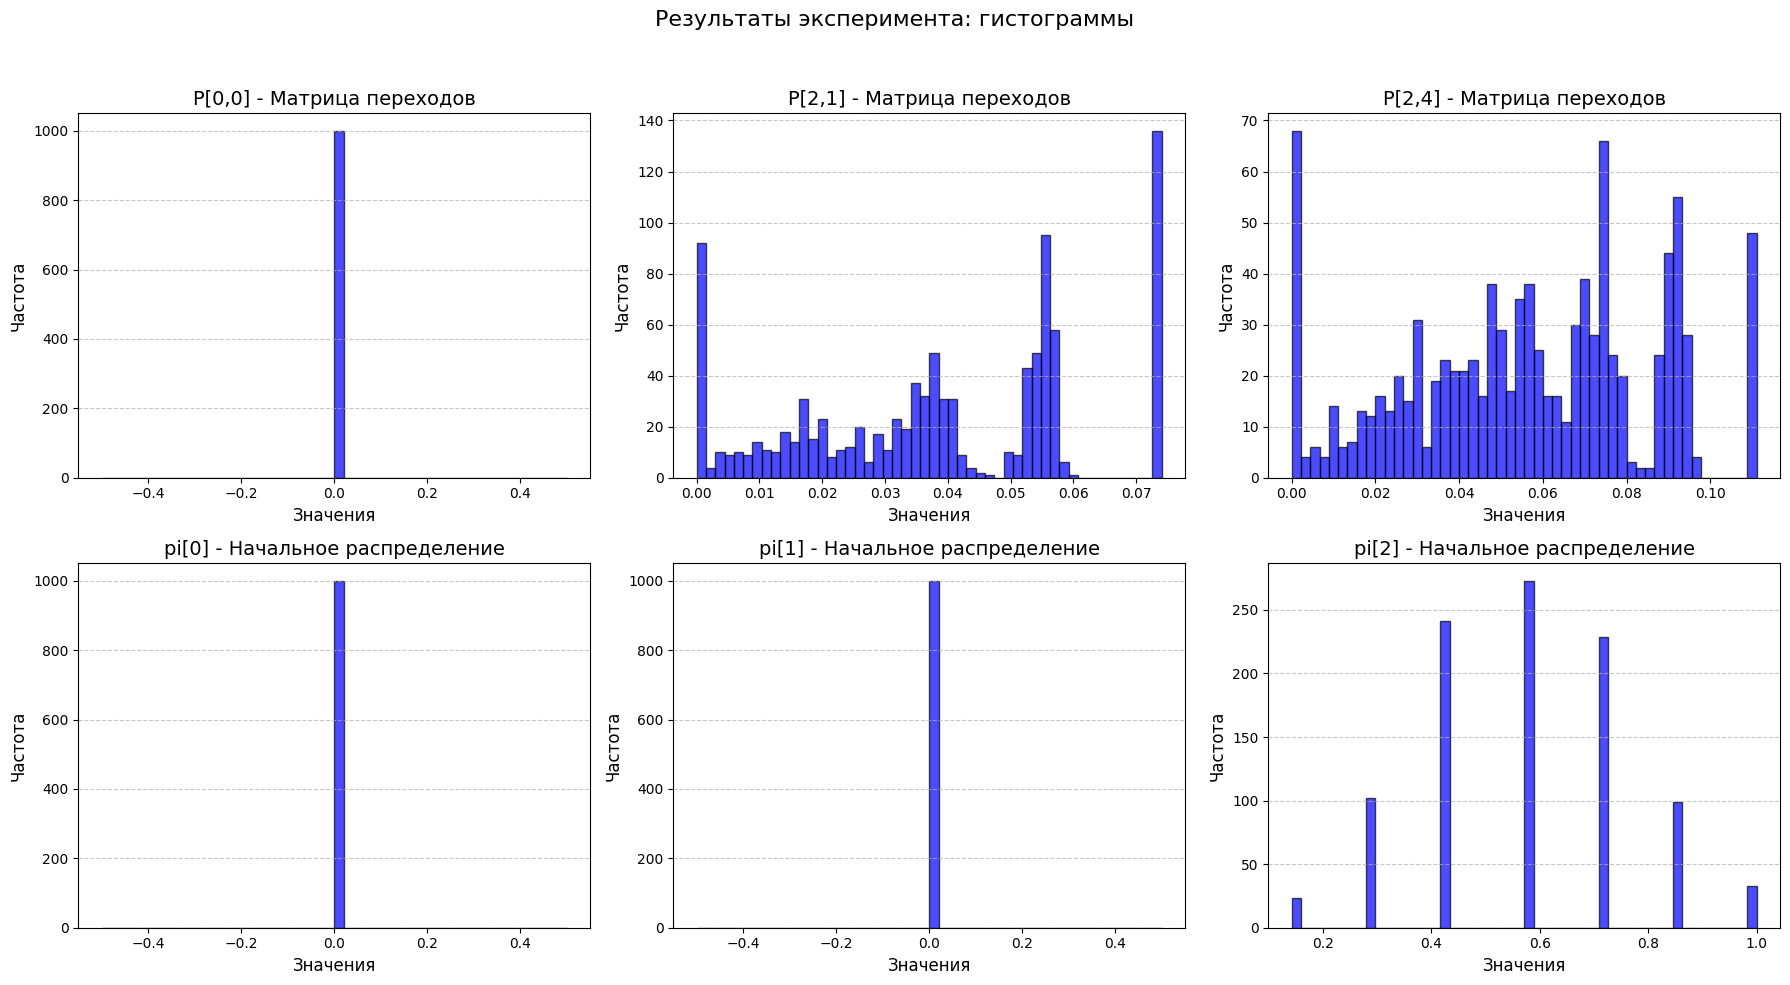

In [74]:
plot_experiment_histograms(np.array(tetta_pi), np.array(tetta_P),bins = 50)

# Задание 3

## Сформируйте выборку предполагаемых значений $\theta^{*}_{1}...\theta^{*}_{n}$ параметра $\theta = (\pi,P)$ c k = 10000 исходя из метода, описанного в п. 7, используя метод Метрополиса-Гастингса.

In [ ]:
from itertools import product
K = 10000
Pi_degree = np.array([sum(data[data["t"]==1]["x"] == k+1)  for k in range(len(Pi))]) # это количество раз, когда состояние k+1 встречается в момент времени t=1
P_degree = np.zeros((len(Pi), len(Pi))) # количесвто переходов из состояния l в m
for l, m in product(range(1, len(Pi)+1),  range(1, len(Pi)+1)):
    for i in range(data.shape[0] - 1):
        if data.iloc[i]["x"] == l and data.iloc[i+1]["x"] == m and data.iloc[i]["sample"] == data.iloc[i+1]["sample"]:
            P_degree[l-1, m-1] += 1


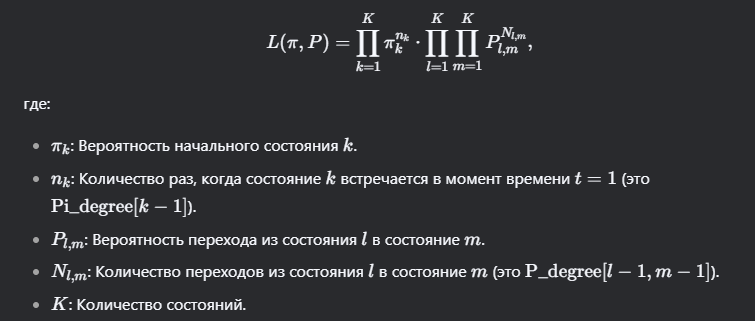

In [130]:
def likelihood_prod(Pi, P,Pi_degree,P_degree):
    _Pi, _P = np.copy(Pi), np.copy(P)
    return np.prod(_Pi ** Pi_degree) * np.prod(_P ** P_degree)

def metropolis_hastings_markov_chain(pi,P, k, sigma2):
    xi_pi = [pi] #piшки
    xi_P = [P]
    curr_xi_pi = xi_pi[0]
    curr_xi_P = xi_P[0]
    accepted_count = 0

    for i in range(1, k):
        # Предложение новых параметров
        eta = np.random.uniform(0, 1)
        pi_gamma = np.random.normal(loc=0, scale = sigma2, size = pi.shape)
        P_gamma = np.random.normal(loc=0, scale = sigma2, size = P.shape)

        pi_theta = pi_gamma + curr_xi_pi
        #pi_theta[:-1] = np.clip(pi_theta[:-1], 0, 1) # чтобы вероятность была не больше 1 обрезаем
        #pi_theta[-1] = 1 - np.sum(pi_theta[:-1])# ///

        P_theta = P_gamma + curr_xi_P

        if np.sum(pi_theta[:]) > 1 or (np.sum(P_theta[:, :], axis=1)  > 1).any():
            xi_pi.append(curr_xi_pi)
            xi_P.append(curr_xi_P)
            continue

        #P_theta[:, :-1] = np.clip(P_theta[:, :-1], 0, 1) # исправить!!!!!!!!!!!!! отклоняем, если вылезло за пределы
        #P_theta[:, -1] = 1 - np.sum(P_theta[:, :-1], axis=1)

        acceptance_ratio = likelihood_prod(pi_theta,P_theta,Pi_degree,P_degree) / likelihood_prod(curr_xi_pi,curr_xi_P,Pi_degree,P_degree)

        if eta <= acceptance_ratio:
            accepted_count+=1
            xi_pi.append(pi_theta)
            xi_P.append(P_theta)

            curr_xi_pi = pi_theta
            curr_xi_P = P_theta
        else:
            xi_pi.append(curr_xi_pi)
            xi_P.append(curr_xi_P)
    print((accepted_count/k))
    return xi_pi, xi_P

In [132]:
pi_results, P_results = metropolis_hastings_markov_chain(Pi, P, 10000, 0.001)

0.6162


In [88]:
get_variance(pi_results,P_results)


Дисперсия для pi


,Дисперсия
0,0.000651
1,0.000312
2,0.000196
3,0.001103
4,0.003510



Дисперсия для P:


,1,2,3,4,5
1,0.000575,0.000419,0.000703,0.000637,0.003337
2,0.000958,0.001160,0.001651,0.000706,0.000512
3,0.000702,0.000219,0.000148,0.000376,0.000499
4,0.000706,0.000949,0.000371,0.000476,0.002496
5,0.000267,0.000437,0.002442,0.001052,0.000912


In [89]:
get_quantile(P_results)

Стандартные отклонения для P(xi(n+1)): [0.02398158 0.02046336 0.02651181 0.02524862 0.05777104]
Стандартные отклонения для P(xi(n+2)): [0.01318564 0.01751912 0.04402078 0.0249126  0.02549341]
0.9 квантильные интервалы для P(xi(n+1)):
Состояние 1: [0.0012, 0.0735]
Состояние 2: [0.0673, 0.1312]
Состояние 3: [0.0406, 0.1152]
Состояние 4: [0.0727, 0.1538]
Состояние 5: [0.5855, 0.7778]
0.9 квантильные интервалы для P(xi(n+2)):
Состояние 1: [0.0902, 0.1320]
Состояние 2: [0.1033, 0.1653]
Состояние 3: [0.2177, 0.3519]
Состояние 4: [0.2662, 0.3438]
Состояние 5: [0.1309, 0.2125]


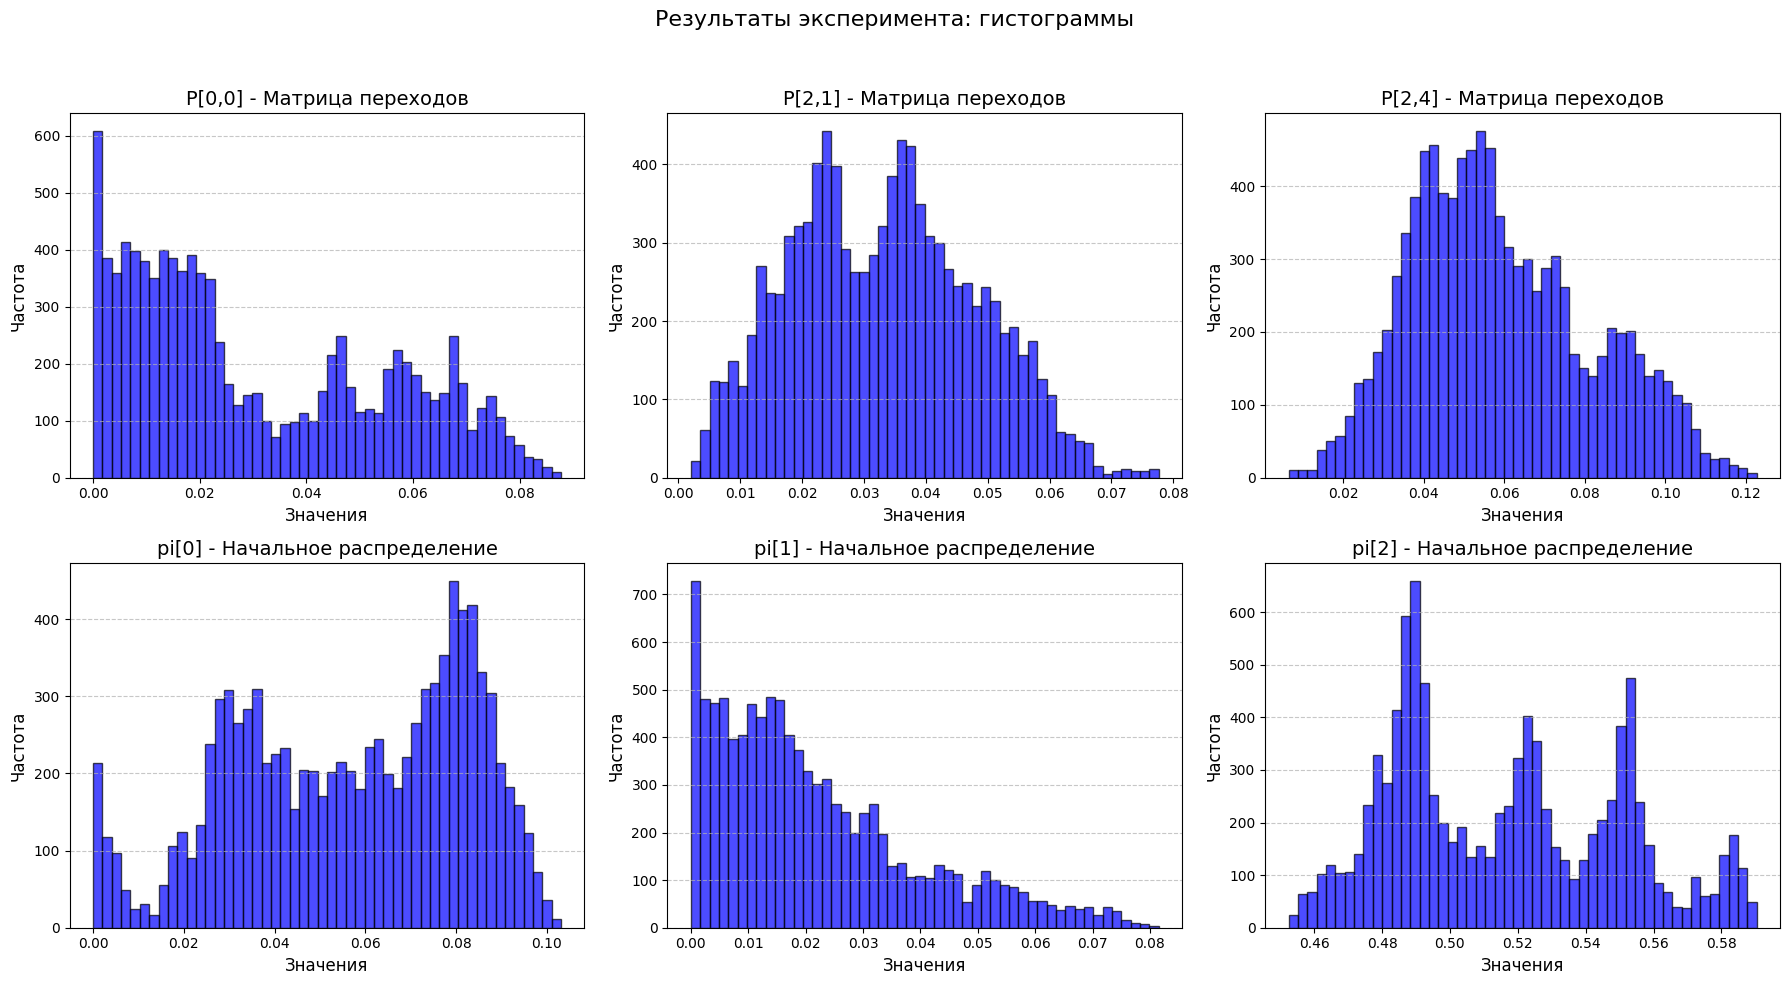

In [90]:
plot_experiment_histograms(np.array(pi_results), np.array(P_results),bins = 50)